## Expanding reaction framework

In [1]:
from pathlib import Path
from rdkit import Chem

from src.utils.dataIO import read_monomer_data, read_rxn_mapping_data
from src.utils.datafmt import parse_field_names_and_roles


DATA_DIR = Path('src/monomer_data')

input_data_path = DATA_DIR / 'PolyID_master.csv'
# input_data_path = DATA_DIR / 'subsample_IPU.csv'

# load and parse monomer data file from disc
monomer_df = read_monomer_data([input_data_path])[0]
monomer_df.set_index(monomer_df.columns[0], inplace=True) # alternative to index_cols arg in read function
field_names, field_roles = parse_field_names_and_roles(monomer_df)
monomer_df.rename(columns=field_names, inplace=True)
print(len(monomer_df))

# generate chemically-unique counterpart
monomer_df_unique = monomer_df.drop_duplicates('smiles_canonical')
print(len(monomer_df_unique))

3199
2528


## Defining recursively-enumerated fragment generation protocol

### Fetching reactants and reaction template

imide


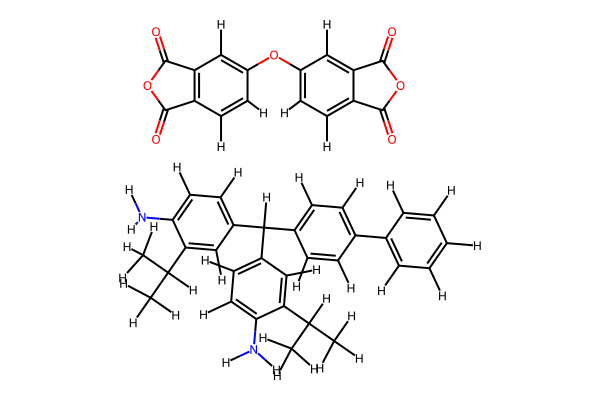

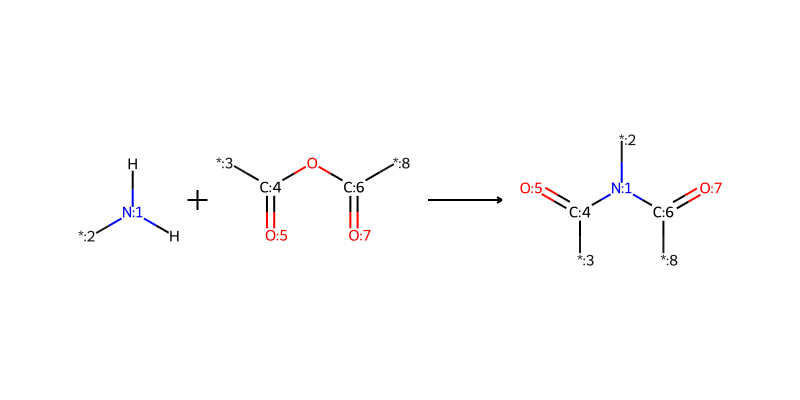

In [2]:
from polymerist.rdutils import set_rdkdraw_size
set_rdkdraw_size(400, 3/2)

from polymerist.rdutils.reactions.reactions import AnnotatedReaction
from polymerist.rdutils.reactions.reactors import PolymerizationReactor
from polymerist.rdutils.reactions.assembly import ReactionAssembler

sample = monomer_df_unique.groupby('mechanism').sample(1)
idxs_by_mechanism = {mechname : idx for idx, mechname in sample['mechanism'].to_dict().items()}

mechanism : str = 'carbonate'
mechanism : str = 'amide'
mechanism : str = 'vinyl'
mechanism : str = 'imide'
# mechanism : str = 'ester'
# mechanism : str = 'urethane'
row = sample.loc[idxs_by_mechanism[mechanism]]
print(row.mechanism)

# get reactants
monomers = Chem.MolFromSmiles(row.smiles_explicit, sanitize=False)
Chem.SanitizeMol(monomers)
Chem.Kekulize(monomers, clearAromaticFlags=True)
Chem.SetAromaticity(monomers, model=Chem.AROMATICITY_MDL)
reactants = Chem.GetMolFrags(monomers, asMols=True)
display(monomers)

# get reaction
rxn = AnnotatedReaction.from_smarts(row.rxn_smarts)
display(rxn)

# Something else